<a href="https://colab.research.google.com/github/VemuriPavanateja2007/Machine-Learning/blob/main/Email_Spam_Detection_using_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows of dataset:
   Unnamed: 0 label                                               text  \
0         605   ham  Subject: enron methanol ; meter # : 988291\r\n...   
1        2349   ham  Subject: hpl nom for january 9 , 2001\r\n( see...   
2        3624   ham  Subject: neon retreat\r\nho ho ho , we ' re ar...   
3        4685  spam  Subject: photoshop , windows , office . cheap ...   
4        2030   ham  Subject: re : indian springs\r\nthis deal is t...   

   label_num  
0          0  
1          0  
2          0  
3          1  
4          0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5171 non-null   int64 
 1   label       5171 non-null   object
 2   text        5171 non-null   object
 3   label_num   5171 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 161.7+ KB
None

Missing values in eac

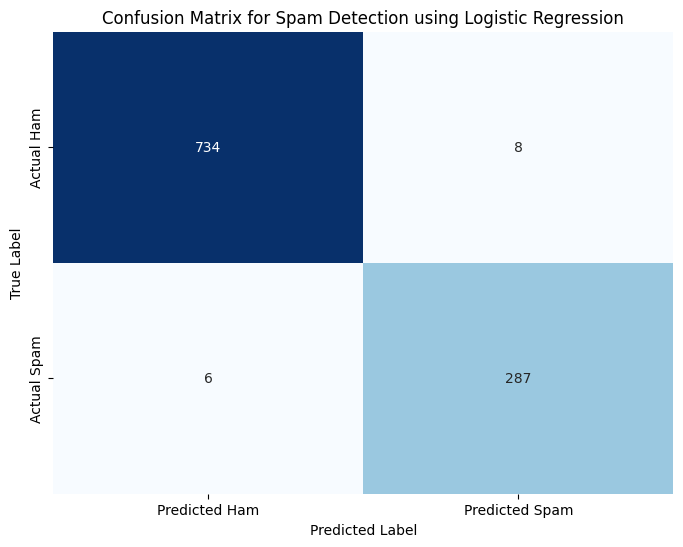

In [ ]:
# ==============================
# Email Spam Detection using Logistic Regression
# For uploaded file: spam_ham_dataset.csv
# ==============================

# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Load dataset
df = pd.read_csv('spam_ham_dataset.csv')

# Display first 5 rows
print("First 5 rows of dataset:")
print(df.head())

# Display dataset information
print("\nDataset Info:")
print(df.info())

# Check missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# ------------------------------
# Select text and target columns
# ------------------------------
# Change these column names if needed after checking df.columns
print("\nColumn names in dataset:")
print(df.columns)

# Usually datasets have columns like 'text' and 'label'
# Adjust according to your dataset
text_column = 'text'
target_column = 'label'

# Drop missing values in important columns
df = df[[text_column, target_column]].dropna()

# Convert labels into numeric form
# ham = 0, spam = 1
df[target_column] = df[target_column].map({'ham': 0, 'spam': 1})

# Print class distribution
print("\nClass distribution:")
print(df[target_column].value_counts())

# Features and target
X = df[text_column]
y = df[target_column]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# --------------------------------
# Convert text data into TF-IDF form
# --------------------------------
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("\nText converted into TF-IDF features successfully!")
print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

# Train Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_tfidf, y_train)

print("\nLogistic Regression model trained successfully!")

# Predictions
y_pred = model.predict(X_test_tfidf)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Predicted Ham', 'Predicted Spam'],
    yticklabels=['Actual Ham', 'Actual Spam']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Spam Detection using Logistic Regression')
plt.show()